# Unsupervised SPI–SPI recovery of the Kuramoto order parameter

**Prospective terminal test.** The SPI–SPI representation and all gates were frozen before this bank was generated. The primary physical target is the canonical finite-population phase coherence

$$R_N(t)=\left|N^{-1}\sum_j e^{i\theta_j(t)}\right|,$$

averaged over a disjoint future of the hidden $N=256$ system. SPI–SPI sees only $M=20$ channels of $\cos\theta$ for $T=1000$. Numerical $q\mapsto R_N$ calibration is supervised and is reported separately from unsupervised coordinate recovery.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import spearmanr

ROOT = Path.cwd()
CONTRACT = ROOT / "data/order_parameter/kuramoto_final_confirmation_contract"
summary = json.loads((CONTRACT / "confirmation_summary.json").read_text())
representation = json.loads((CONTRACT / "representation_contract.json").read_text())
eligibility = json.loads((CONTRACT / "confirmation_eligibility.json").read_text())
shift_path = CONTRACT / "shift_control_summary.json"
shift = json.loads(shift_path.read_text()) if shift_path.exists() else None
archive = np.load(CONTRACT / "confirmation_results.npz", allow_pickle=False)
frame = pd.DataFrame({name: archive[name] for name in (
    "class_name", "distribution", "frequency_sampling", "design", "kappa", "instance",
    "coordinate_pc1", "coordinate_diffusion", "target_full_future_R",
    "target_hidden_complement_future_R", "prediction_R", "prediction_kappa_baseline_R",
)})
sns.set_theme(style="whitegrid", context="notebook")
print(f"status={summary['status']}; rows={len(frame)}; target opened={eligibility['outcomes_read']}")

status=passed; rows=1536; target opened=True


## Assay and frozen gates

The first prospective bank is retained as a disclosed eligibility null: three rows made the original 197-SPI core non-finite, and no $R_N$ was read. Exactly one target-blind redesign was allowed. It retained SPIs finite and nonconstant on every old plus eligibility-null input row; this terminal bank permits no further redesign.

The terminal analysis wrote and passed eligibility before loading targets. Its eligibility JSON was subsequently updated to record target access rather than preserving an immutable pre-read copy; the code ordering is auditable, and future runs now create a separate exclusive pre-read artifact.

In [2]:
gate_table = pd.DataFrame({
    "gate": list(summary["gate_results"]),
    "passed": list(summary["gate_results"].values()),
})
display(pd.DataFrame({
    "quantity": ["core SPIs", "SPI–SPI pairs", "PC1 features", "PC1 variance", "bootstrap loading p05", "bootstrap coordinate p05", "worst leave-group loading", "worst leave-group coordinate"],
    "value": [representation["core_spis"], representation["core_meta_features"], representation["retained_pc_features"], representation["pc_explained_variance_ratio"], representation["pc_stability"]["bootstrap_p05_loading_cosine"], representation["pc_stability"]["bootstrap_p05_coordinate_spearman"], representation["pc_stability"]["leave_group_minimum_loading_cosine"], representation["pc_stability"]["leave_group_minimum_coordinate_spearman"]],
}).round(4))
display(gate_table)

,quantity,value
0,core SPIs,164.0000
1,SPI–SPI pairs,13366.0000
2,PC1 features,12737.0000
3,PC1 variance,0.3612
4,bootstrap loading p05,0.9905
5,bootstrap coordinate p05,0.9983
6,worst leave-group loading,0.9687
7,worst leave-group coordinate,0.9928


,gate,passed
0,gaussian_beats_intercept,True
1,gaussian_hidden_within,True
2,gaussian_numerical_mae,True
3,gaussian_overall,True
4,gaussian_within,True
5,logistic_beats_intercept,True
6,logistic_hidden_within,True
7,logistic_numerical_mae,True
8,logistic_overall,True
9,logistic_within,True


## Primary result

PC1 has arbitrary sign. Its sign below is oriented after target reveal only for display; every reported gate uses absolute rank association. Random-frequency paired paths are primary. Independent-cell and regular-frequency rows are sensitivities.

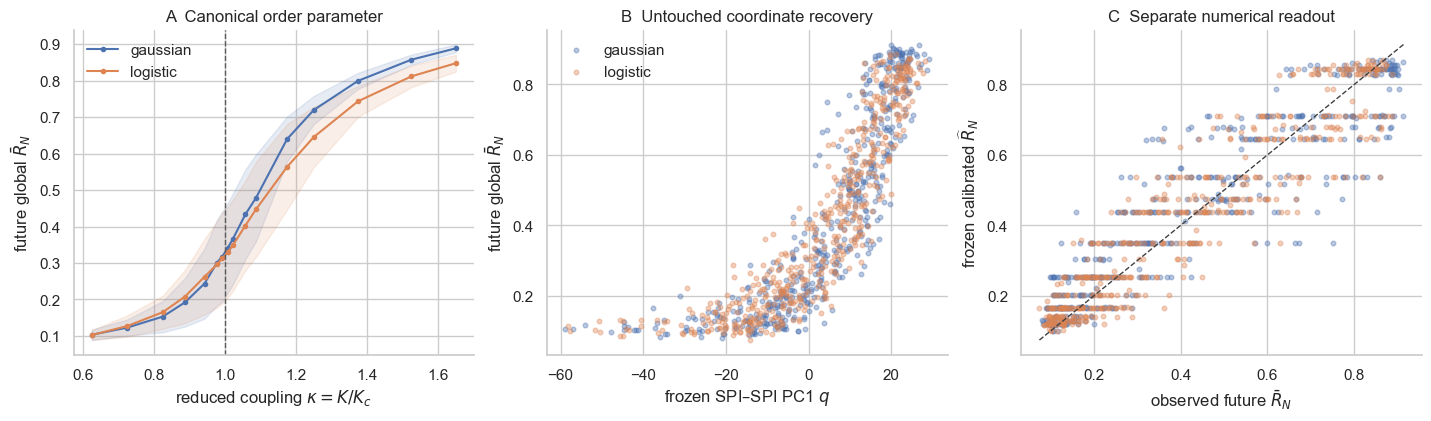

,overall rho,overall |rho| CI lower,within-kappa rho,within-kappa |rho| CI lower,MAE,MAE CI upper
gaussian,-0.924,0.904,-0.523,0.362,0.080,0.092
logistic,-0.933,0.917,-0.618,0.463,0.069,0.079


In [3]:
primary = frame.query("frequency_sampling == 'random' and design == 'paired'").copy()
sign = np.sign(spearmanr(primary.coordinate_pc1, primary.target_full_future_R).statistic) or 1.0
frame["q"] = sign * frame.coordinate_pc1
primary = frame.query("frequency_sampling == 'random' and design == 'paired'").copy()

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.1), constrained_layout=True)
colors = {"gaussian": "C0", "logistic": "C1"}
for dist, group in primary.groupby("distribution"):
    curve = group.groupby("kappa").target_full_future_R.agg(["mean", "std"]).reset_index()
    axes[0].fill_between(curve.kappa, curve["mean"]-curve["std"], curve["mean"]+curve["std"], color=colors[dist], alpha=.13)
    axes[0].plot(curve.kappa, curve["mean"], "-o", ms=3, color=colors[dist], label=dist)
axes[0].axvline(1, color=".35", ls="--", lw=1)
axes[0].set(xlabel=r"reduced coupling $\kappa=K/K_c$", ylabel=r"future global $\bar R_N$", title="A  Canonical order parameter")
axes[0].legend(frameon=False)

for dist, group in primary.groupby("distribution"):
    axes[1].scatter(group.q, group.target_full_future_R, s=11, alpha=.38, color=colors[dist], label=dist)
axes[1].set(xlabel=r"frozen SPI–SPI PC1 $q$", ylabel=r"future global $\bar R_N$", title="B  Untouched coordinate recovery")
axes[1].legend(frameon=False)

for dist, group in primary.groupby("distribution"):
    axes[2].scatter(group.target_full_future_R, group.prediction_R, s=11, alpha=.38, color=colors[dist], label=dist)
limits = [primary.target_full_future_R.min(), primary.target_full_future_R.max()]
axes[2].plot(limits, limits, color=".25", ls="--", lw=1)
axes[2].set(xlabel=r"observed future $\bar R_N$", ylabel=r"frozen calibrated $\widehat R_N$", title="C  Separate numerical readout")
sns.despine(fig)
plt.show()

pd.DataFrame({
    dist: {
        "overall rho": summary["associations"][dist]["full_future_R"]["overall_spearman"],
        "overall |rho| CI lower": summary["associations"][dist]["full_future_R"]["overall_absolute_ci_lower"],
        "within-kappa rho": summary["associations"][dist]["full_future_R"]["within_kappa_spearman"],
        "within-kappa |rho| CI lower": summary["associations"][dist]["full_future_R"]["within_kappa_absolute_ci_lower"],
        "MAE": summary["calibration"][dist]["mae"],
        "MAE CI upper": summary["calibration"][dist]["mae_ci95"][1],
    } for dist in ("gaussian", "logistic")
}).T.round(3)

## Baselines and scope

Simple statistics are mandatory comparators, not advantage gates. A baseline may outperform SPI–SPI without invalidating coordinate recovery; it only prevents a superiority claim.

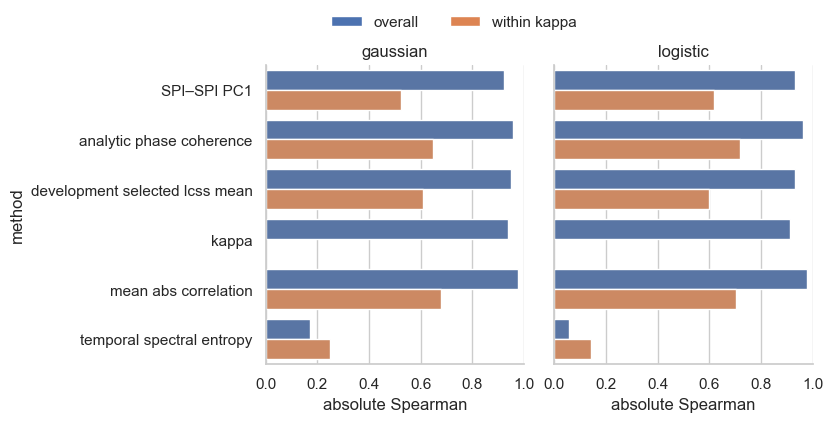

,distribution,method,overall,within kappa
0,gaussian,SPI–SPI PC1,0.924,0.523
1,gaussian,analytic phase coherence,0.958,0.646
2,gaussian,development selected lcss mean,0.950,0.611
3,gaussian,kappa,0.940,NaN
4,gaussian,mean abs correlation,0.975,0.680
5,gaussian,temporal spectral entropy,0.171,0.247
6,logistic,SPI–SPI PC1,0.933,0.618
7,logistic,analytic phase coherence,0.963,0.717
8,logistic,development selected lcss mean,0.933,0.599
9,logistic,kappa,0.913,NaN


In [4]:
rows = []
for dist in ("gaussian", "logistic"):
    block = summary["associations"][dist]["full_future_R"]
    rows.append({"distribution": dist, "method": "SPI–SPI PC1", "overall": abs(block["overall_spearman"]), "within kappa": abs(block["within_kappa_spearman"])})
    for name, values in summary["baseline_associations"][dist].items():
        rows.append({"distribution": dist, "method": name.replace("_", " "), "overall": abs(values["overall_spearman"]), "within kappa": abs(values["within_kappa_spearman"])})
comparison = pd.DataFrame(rows)
plot = comparison.melt(id_vars=["distribution", "method"], var_name="association", value_name="absolute Spearman")
g = sns.catplot(data=plot, y="method", x="absolute Spearman", hue="association", col="distribution", kind="bar", height=4.2, aspect=1.0, legend=False)
g.set(xlim=(0, 1)); g.set_titles("{col_name}")
handles = [Patch(facecolor=sns.color_palette()[0]), Patch(facecolor=sns.color_palette()[1])]
labels = ["overall", "within kappa"]
g.fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(.55, 1.02))
g.fig.subplots_adjust(top=.87); sns.despine()
plt.show()
display(comparison.round(3))

## Sensitivities

In [5]:
sensitivity_rows = []
for dist, blocks in summary["sensitivities"].items():
    for design, values in blocks.items():
        sensitivity_rows.append({
            "distribution": dist, "design": design,
            "overall rho": values["overall_spearman"],
            "within-kappa rho": values["within_kappa_spearman"],
        })
display(pd.DataFrame(sensitivity_rows).round(3))
print(f"Diffusion-map available: {summary['diffusion_map_available']}; rank agreement with PC1: {summary['diffusion_map_pc1_spearman']:.3f}")
if shift is None:
    print("Circular-shift sensitivity not yet present.")
else:
    shift_rows = []
    for dist, values in shift["comparisons"].items():
        shift_rows.append({
            "distribution": dist,
            "raw overall": values["raw_overall_absolute_spearman"],
            "shifted overall": values["shifted_overall_absolute_spearman"],
            "overall difference CI": "[%.3f, %.3f]" % tuple(values["raw_minus_shifted_overall_absolute_spearman_ci95"]),
            "raw within": values["raw_within_kappa_absolute_spearman"],
            "shifted within": values["shifted_within_kappa_absolute_spearman"],
            "within difference CI": "[%.3f, %.3f]" % tuple(values["raw_minus_shifted_within_kappa_absolute_spearman_ci95"]),
        })
    display(pd.DataFrame(shift_rows).round(3))
    print(
        "Shift sensitivity: all frozen features finite = "
        f"{shift['all_frozen_meta_features_finite']}; maximum selected-feature "
        f"missingness = {shift['maximum_selected_feature_missingness']:.3f}."
    )

,distribution,design,overall rho,within-kappa rho
0,gaussian,independent_cell,-0.915,-0.418
1,gaussian,regular_frequency,-0.893,-0.147
2,logistic,independent_cell,-0.909,-0.528
3,logistic,regular_frequency,-0.891,-0.094


Diffusion-map available: True; rank agreement with PC1: 0.981


,distribution,raw overall,shifted overall,overall difference CI,raw within,shifted within,within difference CI
0,gaussian,0.936,0.589,"[0.255, 0.460]",0.672,0.317,"[-0.054, 0.638]"
1,logistic,0.948,0.438,"[0.296, 0.705]",0.643,0.152,"[0.057, 0.682]"


Shift sensitivity: all frozen features finite = False; maximum selected-feature missingness = 0.136.


## Interpretation

The defensible claim depends on the frozen gates above. A pass supports: **in this finite-$N$ Kuramoto benchmark, a prospectively frozen non-phase SPI–SPI PC1 learned without coupling or order-parameter labels recovered, up to a monotone transformation, changes in the canonical phase-coherence order parameter from partial observations on untouched controls and random-frequency realizations under Gaussian and logistic frequency laws.** The numerical $R_N$ estimate uses a separately supervised calibration. Both frequency laws appeared during target-free representation development, so this is not unseen-path transfer. Independent channel shifts substantially reduced overall association, consistent with cross-channel temporal alignment contributing to the representation; shift-induced estimator failures and retained association prevent clean causal attribution. This is a proof of capability, not evidence that SPI–SPI is uniquely optimal or universally recovers order parameters.